# Clustering

## Executive summary

### 1. Implementation of k-Means++

We implemented k-Means++ ourselves. The implementation keeps the current squared distance of every point to the nearest sampled center. When a new center is sampled, only these nearest distances have to be updated. This gives the expected running time of O(nkd) for sampling k centers.

The implementation is then used in two different places. First, it can be used as the initialization method for k-means. Second, and more importantly for this assignment, we use it to sample more than k points for the coreset construction.

### 2. Coreset sampling on MNIST and Fashion-MNIST

We tested the coreset method on both MNIST and Fashion-MNIST. For the coreset construction, we followed the method from the lecture notes. We first sample m points with k-Means++, where m is larger than the final number of clusters k. Then every original point is assigned to its nearest sampled coreset point. The weight of a coreset point is the number of original points assigned to it.

The weights are important because the sampled points do not all represent the same number of original points. Without weights, a point representing many images would count the same as a point representing only a few images. With weights, Lloyd's algorithm can use the coreset as a compressed version of the full dataset.

We used k = 3, 6, 10 and several different coreset sizes. The full dataset run with coreset size 0 is used as the baseline.

### 3. Evaluation of the coresets

#### 3.1 Lloyd's algorithm on coresets

We ran sklearn's Lloyd implementation on the weighted coresets and also on the full datasets. For each final clustering, we measured the objective value on the full dataset and on the weighted coreset.

The full objective value generally improves when the coreset size increases. Very small coresets are not reliable. This is especially visible when the coreset size is close to k, because Lloyd's algorithm can fit the coreset very well while the resulting centers are still not very good on the full dataset.

The weighted coreset objective is usually much smaller than the full objective. This is expected because it is measured only on the compressed representation. For small coresets it is too optimistic, but it increases and becomes more meaningful as the coreset size grows. In our experiments, the coreset objective and the full objective are still not equal for the tested sizes, but the full objective becomes better and more stable for larger coresets.

For the question how many coreset points are needed, the main trend is clear: larger coresets work better. Among the tested sizes, m = 100 gave the best objective values. Smaller sizes, especially m close to k, often had high variance and worse full objective values.

For the running time, the Lloyd step on the coreset is much faster than Lloyd on the full dataset. However, the construction of the coreset is the expensive part in our implementation. The total time with coreset generation grows almost linearly with the coreset size. So coresets do not automatically improve the total running time. If we only look at the Lloyd step, they are much faster. If we include construction time, there is a trade-off between better objective values and the time needed to construct the coreset.

#### 3.2 Additional quality measure

As a second quality measure, we checked how well the coreset points cover the full dataset. For every original point, we computed the squared distance to the nearest coreset point and averaged these values.

This metric is different from running Lloyd's algorithm on the coreset. It evaluates the sampled coreset points directly, before they are used to compute k final centers. A low value means that the original data points are close to some sampled coreset point, so the coreset gives a better geometric representation of the full dataset.

This coverage cost decreases clearly when the coreset size increases, on both MNIST and Fashion-MNIST. This supports the same conclusion as the objective values: larger coresets represent the data better. Among the tested sizes, m = 100 gave the best coverage, but it also had the highest construction time.

#### 3.3 Means and standard deviations

Each parameter setting was repeated five times. We report means and standard deviations for the objective values and for the coverage cost. The standard deviations are larger for small coresets, so a single run would be misleading.

This is especially important for small coreset sizes. Some runs sample useful representative points, while other runs miss important parts of the dataset. For larger coresets, the variance usually becomes smaller and the results become more stable. This is another reason why the largest tested coreset size gave the most reliable results.

## Clustering using Lloyd's algorithm

In [47]:
from PIL.ImageChops import difference
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.datasets import mnist
import numpy as np
import time
from sklearn.metrics import pairwise_distances_argmin_min

# Load MNIST or Fashion-MNIST
(x_train, _), _ = mnist.load_data()
(x_train_fashion, _), _ = fashion_mnist.load_data() # use this line to load Fashion MNIST

# Flatten and scale images
X = x_train.reshape(len(x_train), -1)  # shape: (60000, 784)
X = StandardScaler().fit_transform(X)
X_fashion = x_train_fashion.reshape(len(x_train_fashion), -1)  # shape: (60000, 784)
X_fashion = StandardScaler().fit_transform(X_fashion)

datasets = {
    "MNIST": X,
    "Fashion-MNIST": X_fashion,
}

In [48]:
# K-Means clustering
kmeans = KMeans(n_clusters=10)
kmeans.fit(datasets["MNIST"])
kmeans_fashion = KMeans(n_clusters=10)
kmeans_fashion.fit(datasets["Fashion-MNIST"])

# Output objective function value (inertia_)
print(f'K-Means objective (inertia): {kmeans.inertia_:.2f}')
print(f'K-Means_fashion objective (inertia): {kmeans_fashion.inertia_:.2f}')

K-Means objective (inertia): 36418755.81
K-Means_fashion objective (inertia): 26148062.86


## Implementation of $k$-Means++

In [49]:
def k_means_plus_plus(X, k):
  x = X[np.random.randint(0, X.shape[0])]
  T = [x]
  min_distances = np.full(X.shape[0], np.inf)
  while len(T) < k: # happens k times
    # calculate the distances to the newest center
    z = T[-1]
    new_distances = np.sum((X - z) ** 2, axis=1) # O(n*d)

    # find the cost(x, T) for all X
    # cost_x = np.min(cost_for_each_point, axis=0) # O(n*k)
    cost_x = np.minimum(min_distances, new_distances) # O(n)
    cost_T = np.sum(cost_x) # O(n)

    # randomly select a new point with the calculated probability
    sampled_index = np.random.choice(X.shape[0], p=(cost_x/cost_T)) # O(n)
    T.append(X[sampled_index])

    min_distances = cost_x
  return T


## Sampling Coresets

In [50]:
def sample_coreset(X, m):
    coreset = k_means_plus_plus(X,m)

    closest_indices, _ = pairwise_distances_argmin_min(X, coreset)
    weights = np.bincount(closest_indices, minlength=len(coreset))

    return coreset, weights

## Experimental Evaluation

### Running Lloyd's algorithm on coresets
1. Given your final clustering, how closely does the objective function value on the coreset match the objective function value on the entire dataset?

Running Lloyd's algorithm with clustering is up to 2 times worse than running on the entire dataset.

2. How many points do you need in the coreset to get good results (as a function of k)?

The best result is if we use the most amount of points. But we also need to account for the slow-down tha calculating the coresets bring.

3. Does this improve the overall running time?

If we only have a few coresets then yes but increasing the number of coresets too much will decrease the time enormously. It is only improved if the generation time of the coresets is smaller than the k-means takes on the entire set. In the plots we can see that it's barely worth it to run it with 10 coresets.

In [51]:
coreset_sizes = [0, 10, 20, 30, 40, 50, 100]
k_s = [3, 6, 10]
num_runs = 5

results = {
    dataset_name: {
        "times_with_generation": [list() for _ in k_s],
        "times_without_generation": [list() for _ in k_s],
        "entire_objectives": [list() for _ in k_s],
        "coreset_objectives": [list() for _ in k_s],
        "entire_objectives_std": [list() for _ in k_s],
        "coreset_objectives_std": [list() for _ in k_s],
        "coverage_costs": [list() for _ in k_s],
        "coverage_costs_std": [list() for _ in k_s],
    }
    for dataset_name in datasets
}

for dataset_name, X_current in datasets.items():
    print(f"Running evaluation for {dataset_name} Dataset")
    for size in coreset_sizes:
        for i, k in enumerate(k_s):
            print(f"Running coreset with size: {size} and k: {k}")
            run_times_with_generation = []
            run_times_without_generation = []
            run_entire_objectives = []
            run_coreset_objectives = []
            run_coverage_costs = []

            for run in range(num_runs):
                kmeans = KMeans(n_clusters=k)
                if size == 0:
                    start_time = time.perf_counter()

                    kmeans.fit(X_current)

                    end_time = time.perf_counter()

                    run_times_with_generation.append(end_time - start_time)
                    run_times_without_generation.append(end_time - start_time)

                    run_entire_objectives.append(kmeans.inertia_)
                    run_coreset_objectives.append(np.nan)
                    run_coverage_costs.append(np.nan)
                else:
                    start_time = time.perf_counter()

                    coreset, weights = sample_coreset(X_current, size)

                    after_generation_time = time.perf_counter()

                    kmeans.fit(coreset, sample_weight=weights)

                    end_time = time.perf_counter()

                    # calculate error
                    learned_centers = kmeans.cluster_centers_
                    closest_center_indices, distances = pairwise_distances_argmin_min(X_current, learned_centers)
                    closest_coreset_indices, coreset_distances = pairwise_distances_argmin_min(X_current, coreset)

                    run_times_with_generation.append(end_time - start_time)
                    run_times_without_generation.append(end_time - after_generation_time)

                    run_entire_objectives.append(np.sum(distances ** 2))
                    run_coreset_objectives.append(kmeans.inertia_)
                    run_coverage_costs.append(np.mean(coreset_distances ** 2))

            results[dataset_name]["times_with_generation"][i].append(np.mean(run_times_with_generation))
            results[dataset_name]["times_without_generation"][i].append(np.mean(run_times_without_generation))

            results[dataset_name]["entire_objectives"][i].append(np.mean(run_entire_objectives))
            results[dataset_name]["entire_objectives_std"][i].append(np.std(run_entire_objectives))
            if size == 0:
                results[dataset_name]["coreset_objectives"][i].append(np.nan)
                results[dataset_name]["coreset_objectives_std"][i].append(np.nan)
                results[dataset_name]["coverage_costs"][i].append(np.nan)
                results[dataset_name]["coverage_costs_std"][i].append(np.nan)
            else:
                results[dataset_name]["coreset_objectives"][i].append(np.mean(run_coreset_objectives))
                results[dataset_name]["coreset_objectives_std"][i].append(np.std(run_coreset_objectives))
                results[dataset_name]["coverage_costs"][i].append(np.mean(run_coverage_costs))
                results[dataset_name]["coverage_costs_std"][i].append(np.std(run_coverage_costs))


Running evaluation for MNIST Dataset
Running coreset with size: 0 and k: 3
Running coreset with size: 0 and k: 6
Running coreset with size: 0 and k: 10
Running coreset with size: 10 and k: 3
Running coreset with size: 10 and k: 6
Running coreset with size: 10 and k: 10
Running coreset with size: 20 and k: 3
Running coreset with size: 20 and k: 6
Running coreset with size: 20 and k: 10
Running coreset with size: 30 and k: 3
Running coreset with size: 30 and k: 6
Running coreset with size: 30 and k: 10
Running coreset with size: 40 and k: 3
Running coreset with size: 40 and k: 6
Running coreset with size: 40 and k: 10
Running coreset with size: 50 and k: 3
Running coreset with size: 50 and k: 6
Running coreset with size: 50 and k: 10
Running coreset with size: 100 and k: 3
Running coreset with size: 100 and k: 6
Running coreset with size: 100 and k: 10
Running evaluation for Fashion-MNIST Dataset
Running coreset with size: 0 and k: 3
Running coreset with size: 0 and k: 6
Running coreset 

#### Plot

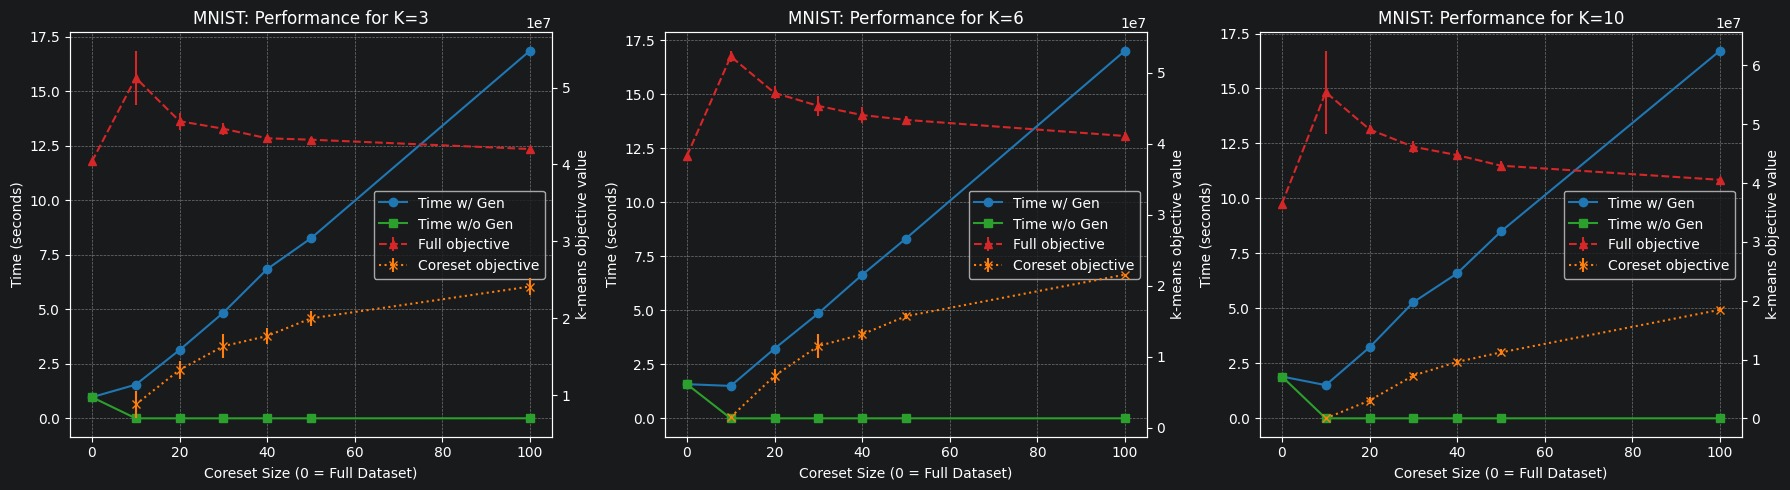

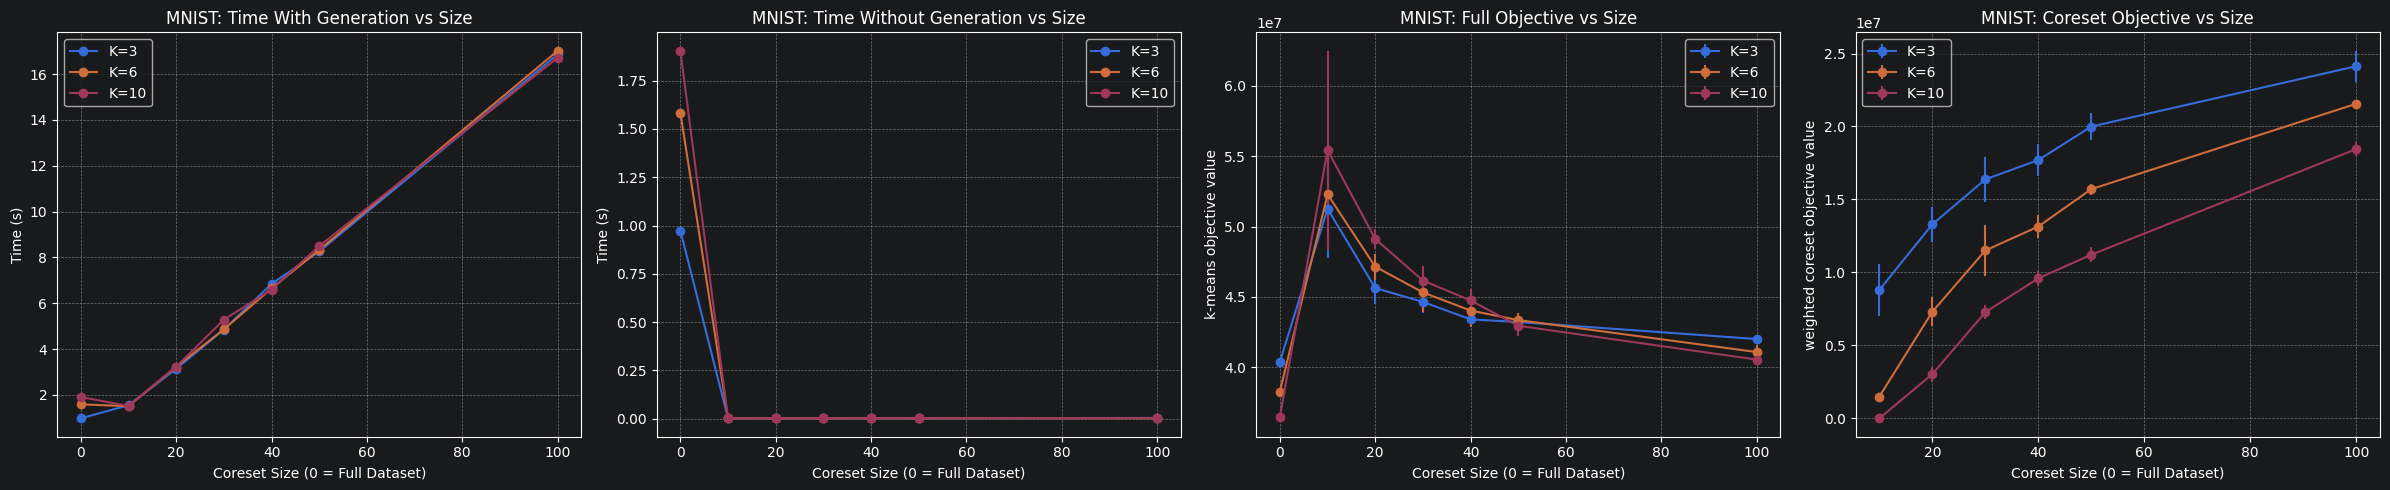

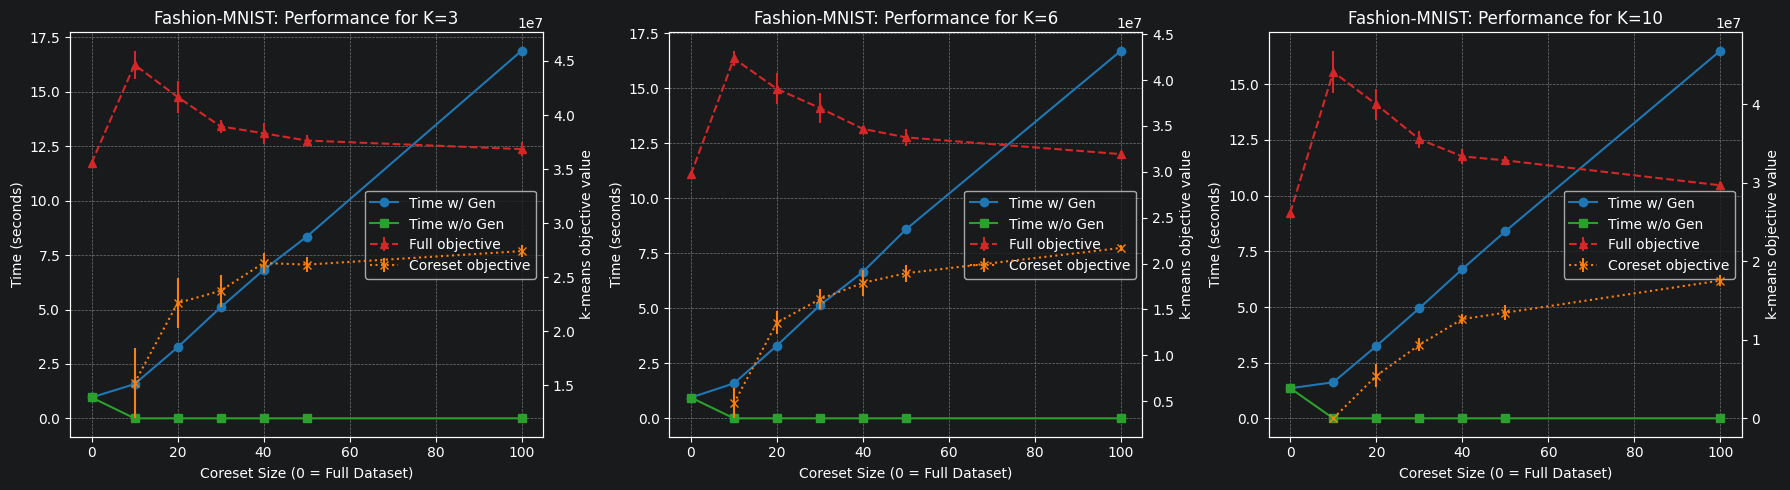

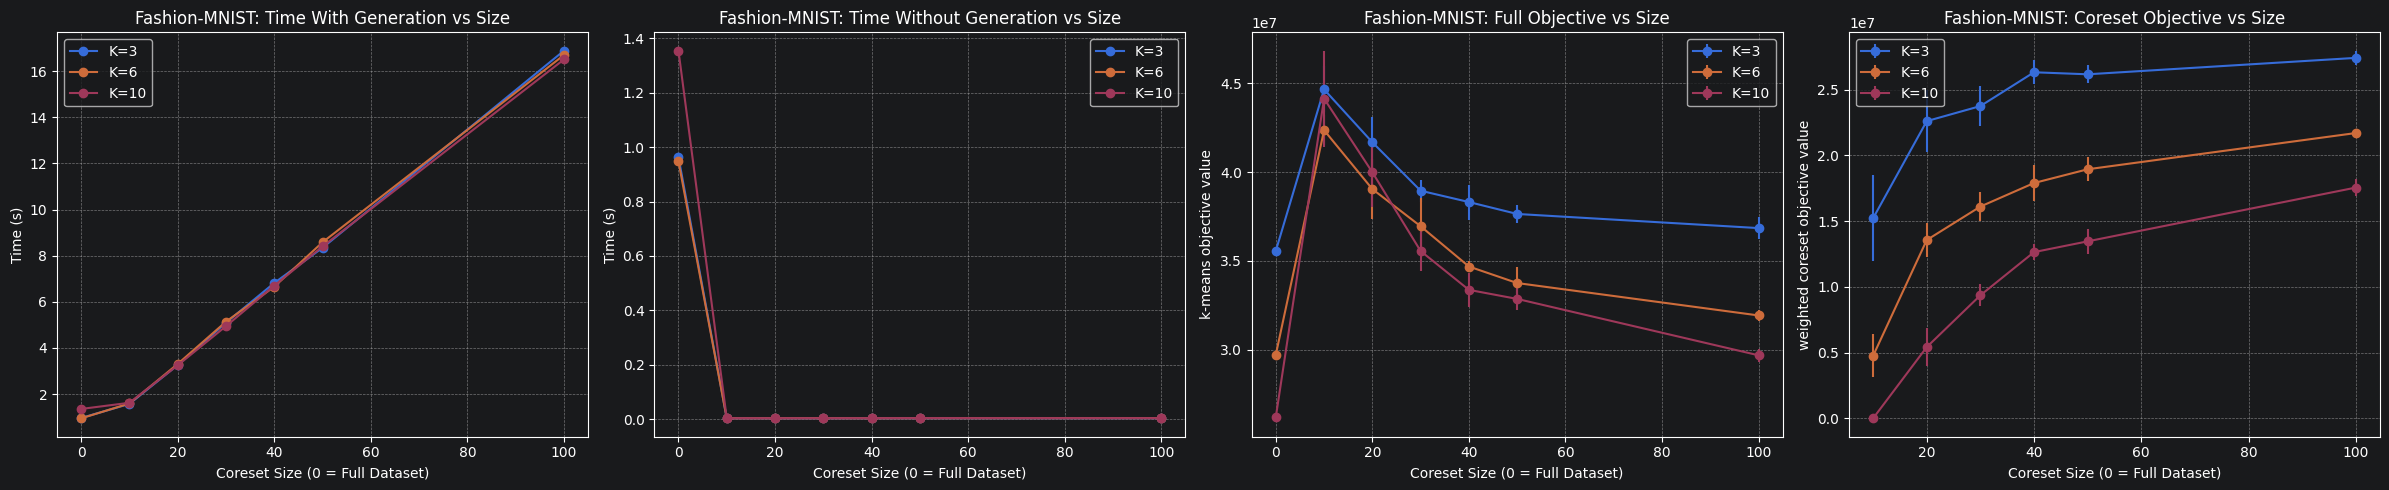

In [52]:
for dataset_name, dataset_results in results.items():
    # --- PLOT SET 1: Metrics grouped by K ---
    fig1, axes1 = plt.subplots(1, 3, figsize=(18, 5))

    for i, k in enumerate(k_s):
        ax = axes1[i]
        # Filter out NaNs (from when size < k) for clean plotting
        valid_idx = ~np.isnan(dataset_results["times_with_generation"][i])
        sizes_valid = np.array(coreset_sizes)[valid_idx]

        ax.plot(sizes_valid, np.array(dataset_results["times_with_generation"][i])[valid_idx], label='Time w/ Gen', marker='o', color='tab:blue')
        ax.plot(sizes_valid, np.array(dataset_results["times_without_generation"][i])[valid_idx], label='Time w/o Gen', marker='s', color='tab:green')

        ax.set_title(f'{dataset_name}: Performance for K={k}')
        ax.set_xlabel('Coreset Size (0 = Full Dataset)')
        ax.set_ylabel('Time (seconds)')
        ax.grid(True, linestyle='--', alpha=0.6)

        # Plot objective values on a twin Y-axis so the scale doesn't ruin the Time plot
        ax2 = ax.twinx()
        ax2.errorbar(sizes_valid, np.array(dataset_results["entire_objectives"][i])[valid_idx], yerr=np.array(dataset_results["entire_objectives_std"][i])[valid_idx], label='Full objective', color='tab:red', marker='^', linestyle='--')
        ax2.errorbar(sizes_valid, np.array(dataset_results["coreset_objectives"][i])[valid_idx], yerr=np.array(dataset_results["coreset_objectives_std"][i])[valid_idx], label='Coreset objective', color='tab:orange', marker='x', linestyle=':')
        ax2.set_ylabel('k-means objective value')

        # Combine legends
        lines_1, labels_1 = ax.get_legend_handles_labels()
        lines_2, labels_2 = ax2.get_legend_handles_labels()
        ax.legend(lines_1 + lines_2, labels_1 + labels_2, loc='center right')

    plt.tight_layout()
    plt.show()

    # --- PLOT SET 2: Comparing K's for each Metric ---
    fig2, axes2 = plt.subplots(1, 4, figsize=(24, 5))

    titles = ['Time With Generation vs Size', 'Time Without Generation vs Size', 'Full Objective vs Size', 'Coreset Objective vs Size']
    y_labels = ['Time (s)', 'Time (s)', 'k-means objective value', 'weighted coreset objective value']
    data_lists = [
        dataset_results["times_with_generation"],
        dataset_results["times_without_generation"],
        dataset_results["entire_objectives"],
        dataset_results["coreset_objectives"]
    ]
    std_lists = [
        None,
        None,
        dataset_results["entire_objectives_std"],
        dataset_results["coreset_objectives_std"]
    ]

    for metric_idx, (title, ylabel, data) in enumerate(zip(titles, y_labels, data_lists)):
        ax = axes2[metric_idx]
        for i, k in enumerate(k_s):
            valid_idx = ~np.isnan(data[i])
            sizes_valid = np.array(coreset_sizes)[valid_idx]
            if std_lists[metric_idx] is None:
                ax.plot(sizes_valid, np.array(data[i])[valid_idx], label=f'K={k}', marker='o')
            else:
                ax.errorbar(sizes_valid, np.array(data[i])[valid_idx], yerr=np.array(std_lists[metric_idx][i])[valid_idx], label=f'K={k}', marker='o')

        ax.set_title(f'{dataset_name}: {title}')
        ax.set_xlabel('Coreset Size (0 = Full Dataset)')
        ax.set_ylabel(ylabel)
        ax.grid(True, linestyle='--', alpha=0.6)
        ax.legend()

    plt.tight_layout()
    plt.show()


### Coverage quality of the coresets

As an additional quality measure, we evaluate how well the sampled coreset points cover the full dataset before running Lloyd's algorithm. For every original point, we find the nearest coreset point and compute the average squared distance. Lower values mean that the coreset is a better geometric representative of the full dataset.

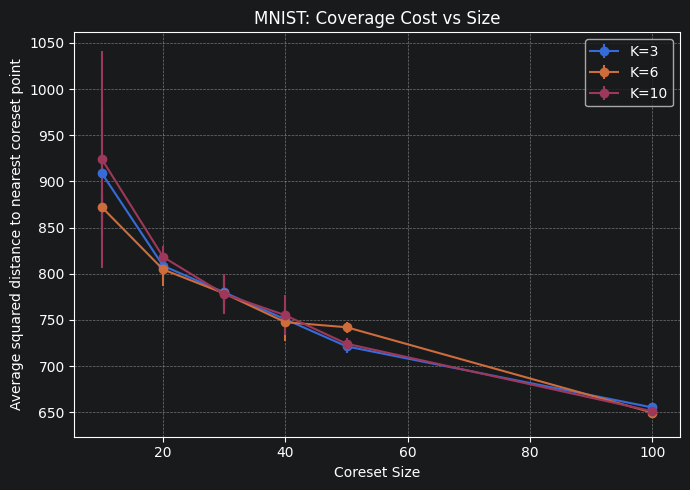

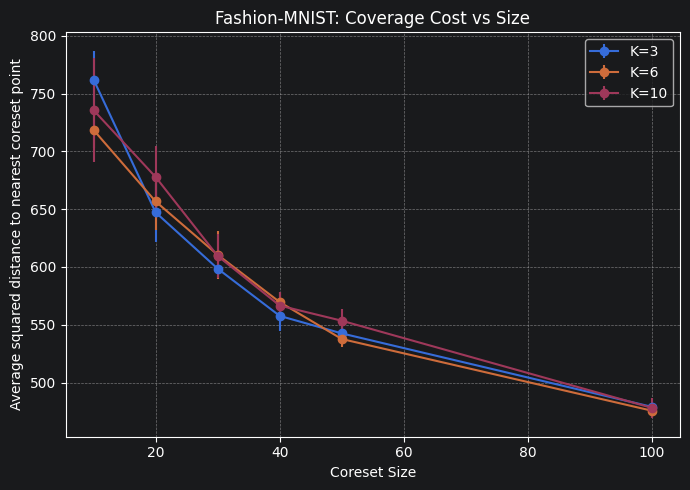

In [53]:
for dataset_name, dataset_results in results.items():
    fig, ax = plt.subplots(figsize=(7, 5))

    for i, k in enumerate(k_s):
        values = np.array(dataset_results["coverage_costs"][i])
        stds = np.array(dataset_results["coverage_costs_std"][i])
        valid_idx = ~np.isnan(values)
        sizes_valid = np.array(coreset_sizes)[valid_idx]

        ax.errorbar(sizes_valid, values[valid_idx], yerr=stds[valid_idx], label=f'K={k}', marker='o')

    ax.set_title(f'{dataset_name}: Coverage Cost vs Size')
    ax.set_xlabel('Coreset Size')
    ax.set_ylabel('Average squared distance to nearest coreset point')
    ax.grid(True, linestyle='--', alpha=0.6)
    ax.legend()

    plt.tight_layout()
    plt.show()